### VISUALIZACION SMQ


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
smq = pd.read_csv("../data/processed/smq_limpio.csv")

# Configuración de estilo global para los gráficos (estilo profesional)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})
# smq = pd.read_csv("../data/processed/smq_limpio.csv")

C:\Users\USER\AppData\Local\Temp\ipykernel_14208\2554857118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=smq, x='SMQ020', palette=['#4C72B0', '#55A868'])


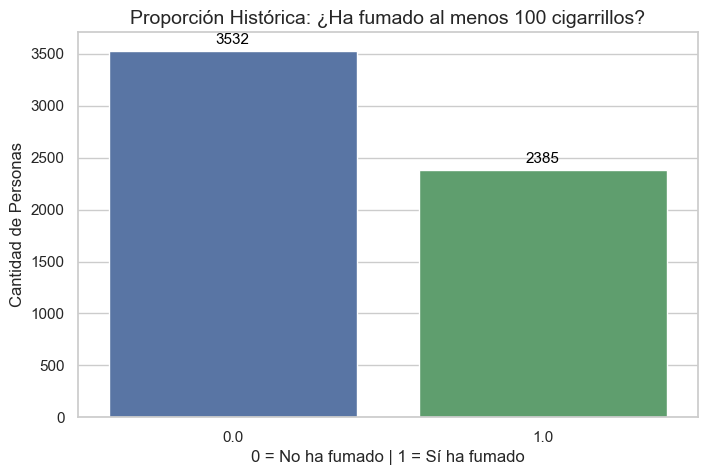

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=smq, x='SMQ020', palette=['#4C72B0', '#55A868'])

plt.title('Proporción Histórica: ¿Ha fumado al menos 100 cigarrillos?')
plt.xlabel('0 = No ha fumado | 1 = Sí ha fumado')
plt.ylabel('Cantidad de Personas')

# Agregar los valores exactos sobre cada barra 
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_14208\1867641886.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=fumadores_historicos, x='SMQ040', palette='Set2')


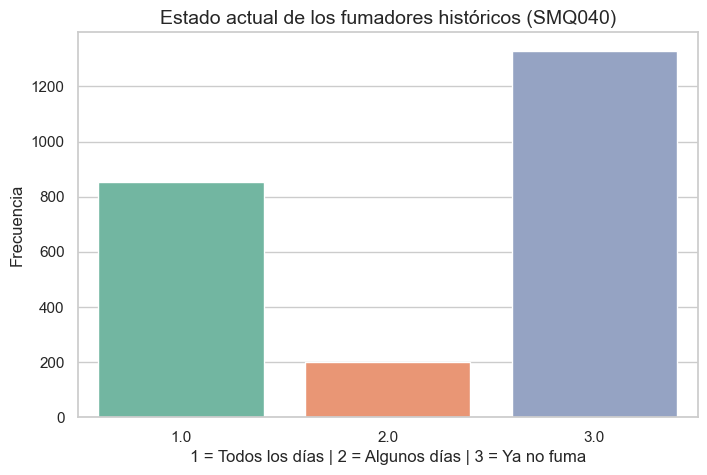

In [28]:
plt.figure(figsize=(8, 5))

fumadores_historicos = smq[smq['SMQ020'] == 1]

ax = sns.countplot(data=fumadores_historicos, x='SMQ040', palette='Set2')
plt.title('Estado actual de los fumadores históricos (SMQ040)')
plt.xlabel('1 = Todos los días | 2 = Algunos días | 3 = Ya no fuma')
plt.ylabel('Frecuencia')
plt.show()

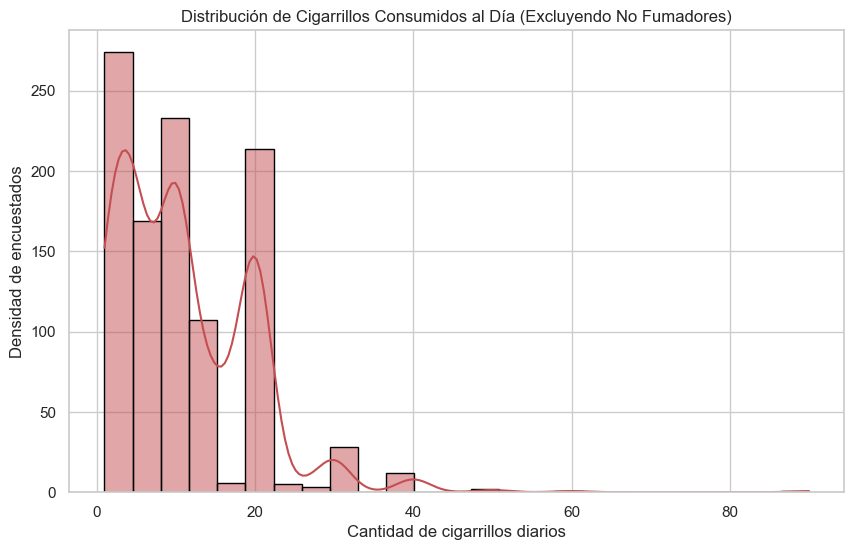

In [59]:
plt.figure(figsize=(10, 6))

# Filtramos a los que fuman > 0 cigarrillos para evitar el pico artificial
fumadores_activos = smq[smq['SMD650'] > 0]

sns.histplot(fumadores_activos['SMD650'], bins=25, kde=True, color='#C44E52', edgecolor='black')
plt.title('Distribución de Cigarrillos Consumidos al Día (Excluyendo No Fumadores)')
plt.xlabel('Cantidad de cigarrillos diarios')
plt.ylabel('Densidad de encuestados')
plt.show()

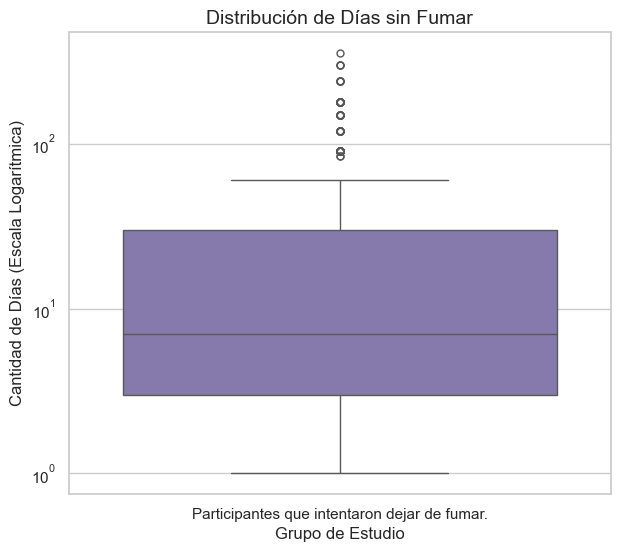

In [60]:
plt.figure(figsize=(7, 6))

intentos_dejar = smq[smq['SMQ852_dias'] > 0].copy()

# TRUCO: Creamos una columna temporal para darle nombre al eje
intentos_dejar['Categoria'] = 'Participantes que intentaron dejar de fumar.'

# Ahora al graficar, le decimos quién es 'x' y quién es 'y'
sns.boxplot(data=intentos_dejar, x='Categoria', y='SMQ852_dias', color='#8172B3', fliersize=5)

plt.title('Distribución de Días sin Fumar', fontsize=14)
plt.ylabel('Cantidad de Días (Escala Logarítmica)')
plt.xlabel('Grupo de Estudio') 
plt.yscale('log') 

plt.show()

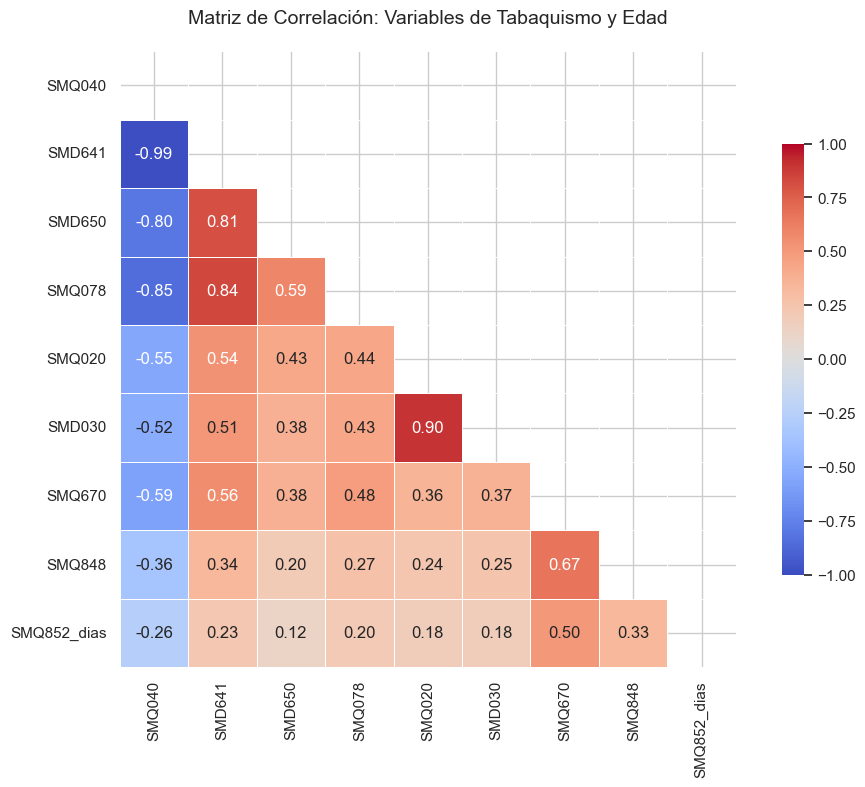

In [31]:
plt.figure(figsize=(12, 8))

# Calculamos la matriz de correlación (quitando SEQN porque es solo el ID)
correlacion_smq = smq.drop(columns=['SEQN']).corr()

# Creamos una máscara para que solo se vea la mitad inferior del triángulo (estilo avanzado)
mask = np.triu(np.ones_like(correlacion_smq, dtype=bool))

sns.heatmap(correlacion_smq, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Matriz de Correlación: Variables de Tabaquismo y Edad', pad=20)
plt.show()

#### Visualización OCQ

C:\Users\USER\AppData\Local\Temp\ipykernel_14208\4009957607.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ocq_plot, y='Tipo_Historial', palette='Set2')


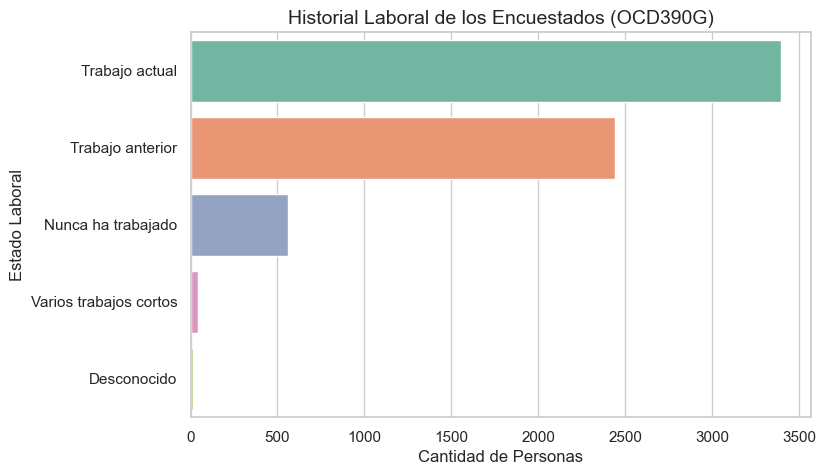

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
ocq = pd.read_csv("../data/processed/ocq_limpio.csv")

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})

plt.figure(figsize=(8, 5))
# Mapeamos para que se entienda la gráfica
ocq_plot = ocq.copy()
ocq_plot['Tipo_Historial'] = ocq_plot['OCD390G'].map({
    1: 'Trabajo actual', 2: 'Trabajo anterior', 
    3: 'Varios trabajos cortos', 4: 'Nunca ha trabajado', 0: 'Desconocido'
})

sns.countplot(data=ocq_plot, y='Tipo_Historial', palette='Set2')
plt.title('Historial Laboral de los Encuestados (OCD390G)')
plt.xlabel('Cantidad de Personas')
plt.ylabel('Estado Laboral')
plt.show()

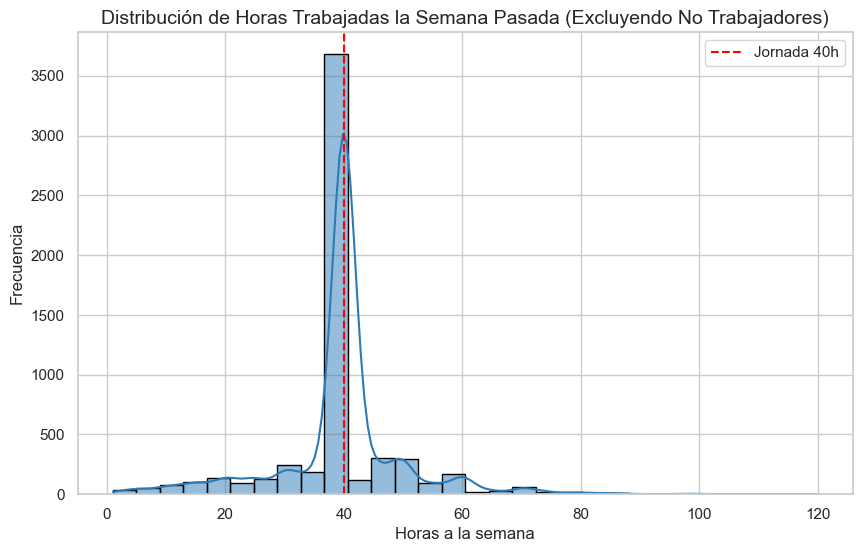

In [35]:
plt.figure(figsize=(10, 6))

# Filtramos a los que trabajan más de 0 horas
trabajadores_activos = ocq[ocq['OCQ180'] > 0]

sns.histplot(trabajadores_activos['OCQ180'], bins=30, kde=True, color='#2C7BB6', edgecolor='black')
plt.title('Distribución de Horas Trabajadas la Semana Pasada (Excluyendo No Trabajadores)')
plt.xlabel('Horas a la semana')
plt.ylabel('Frecuencia')

# Línea vertical para marcar la jornada típica de 40 horas
plt.axvline(40, color='red', linestyle='--', label='Jornada 40h')
plt.legend()
plt.show()

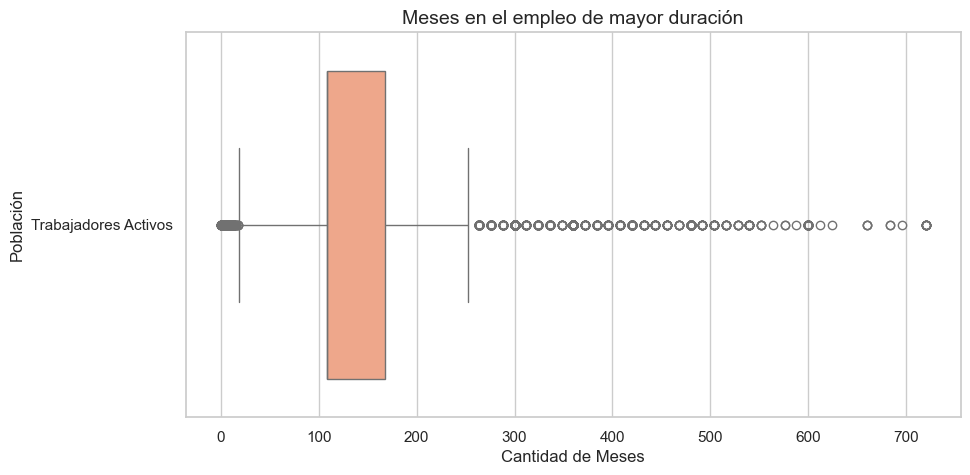

In [56]:
plt.figure(figsize=(10, 5))

estabilidad = ocq[ocq['OCD395'] > 0].copy()
estabilidad['Grupo'] = 'Trabajadores Activos'

# Graficamos poniendo la info en el eje Y
sns.boxplot(data=estabilidad, x='OCD395', y='Grupo', color='#FFA07A')

plt.title('Meses en el empleo de mayor duración', fontsize=14)
plt.xlabel('Cantidad de Meses')
plt.ylabel('Población') # <--- Aquí ya tiene su nombre el eje Y
plt.show()

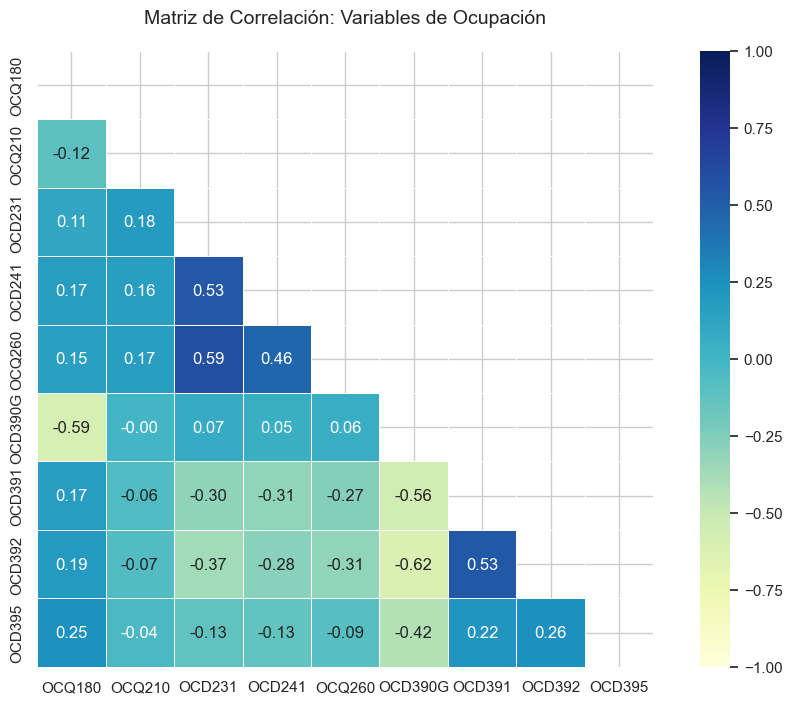

In [ ]:
plt.figure(figsize=(12, 8))

# Calculamos la correlación sin la columna de ID
correlacion_ocq = ocq.drop(columns=['SEQN']).corr()

# Máscara para la mitad inferior 
mask = np.triu(np.ones_like(correlacion_ocq, dtype=bool))

sns.heatmap(correlacion_ocq, mask=mask, annot=True, fmt=".2f", cmap='YlGnBu', 
            vmin=-1, vmax=1, square=True, linewidths=.5)

plt.title('Matriz de Correlación: Variables de Ocupación', pad=20)
plt.show()

#### Visualizacion DLQ

In [20]:
dlq = pd.read_csv("../data/processed/dlq_limpio.csv")
# Estilo profesional
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})

C:\Users\USER\AppData\Local\Temp\ipykernel_14208\201432834.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dlq_sum.values, y=dlq_sum.index, palette="magma")


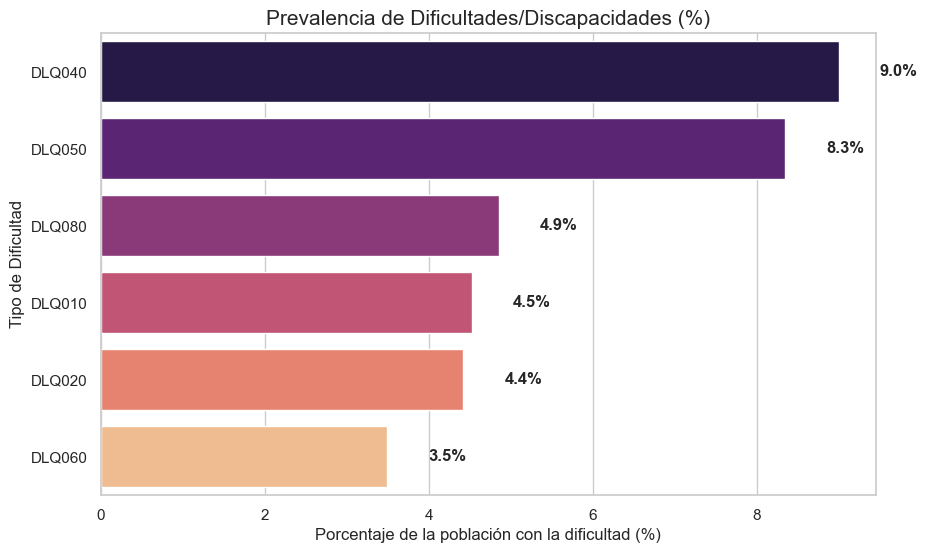

In [21]:
# Calculamos el porcentaje de "Sí" para cada columna
dlq_sum = dlq.drop(columns=['SEQN']).mean() * 100
dlq_sum = dlq_sum.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=dlq_sum.values, y=dlq_sum.index, palette="magma")

plt.title('Prevalencia de Dificultades/Discapacidades (%)', fontsize=15)
plt.xlabel('Porcentaje de la población con la dificultad (%)')
plt.ylabel('Tipo de Dificultad')

# Añadir etiquetas de porcentaje en las barras
for i, v in enumerate(dlq_sum.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.show()

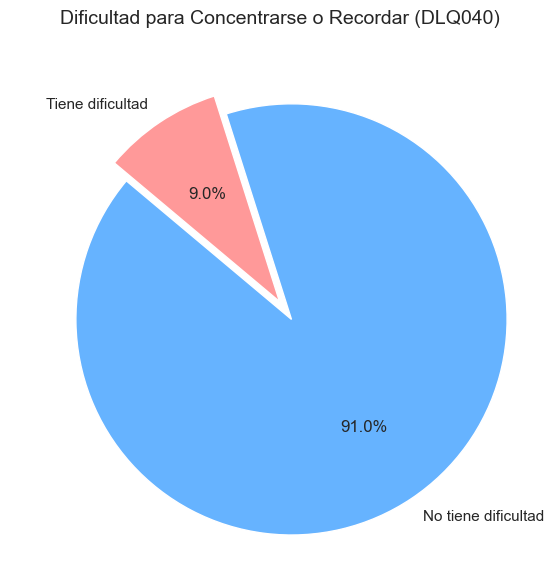

In [23]:
plt.figure(figsize=(7, 7))
data_concentracion = dlq['DLQ040'].value_counts()

plt.pie(data_concentracion, labels=['No tiene dificultad', 'Tiene dificultad'], 
        autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'], explode=(0.1, 0))

plt.title('Dificultad para Concentrarse o Recordar (DLQ040)', fontsize=14)
plt.show()

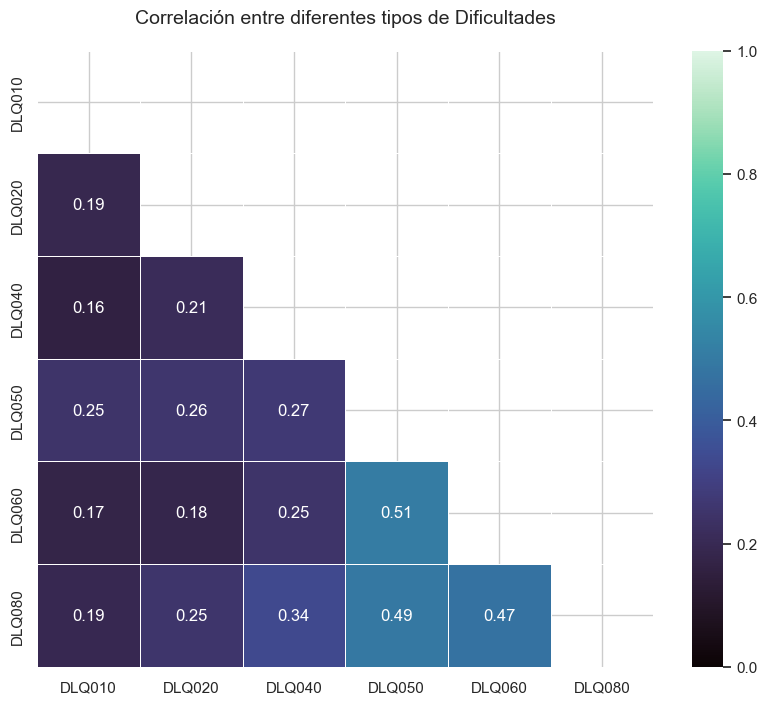

In [ ]:
plt.figure(figsize=(10, 8))

# Calculamos correlación
corr_dlq = dlq.drop(columns=['SEQN']).corr()

mask = np.triu(np.ones_like(corr_dlq, dtype=bool))

sns.heatmap(corr_dlq, mask=mask, annot=True, fmt=".2f", cmap='mako', 
            vmin=0, vmax=1, square=True, linewidths=.5)

plt.title('Correlación entre diferentes tipos de Dificultades', pad=20)
plt.show()

#### Visualización SLQ

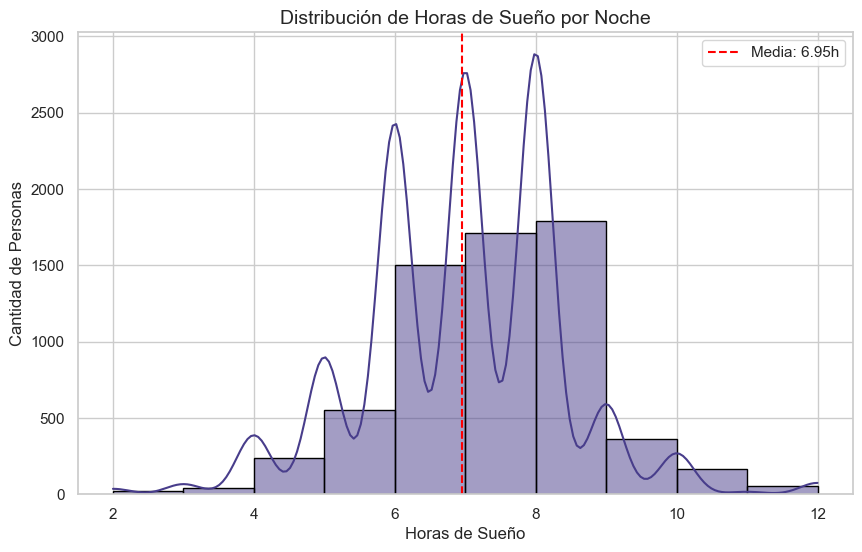

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
slq = pd.read_csv("../data/processed/slq_limpio.csv")

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(10, 6))
# Usamos un histograma con KDE (línea de densidad)
sns.histplot(slq['SLD010H'], bins=10, kde=True, color='#483D8B', edgecolor='black')

plt.title('Distribución de Horas de Sueño por Noche', fontsize=14)
plt.xlabel('Horas de Sueño')
plt.ylabel('Cantidad de Personas')

# Marcamos la media para análisis de salud mental
plt.axvline(slq['SLD010H'].mean(), color='red', linestyle='--', label=f'Media: {slq["SLD010H"].mean():.2f}h')
plt.legend()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_14208\120825489.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=slq_plot, x='Trouble_Sleep', y='SLD010H', palette='Set3')


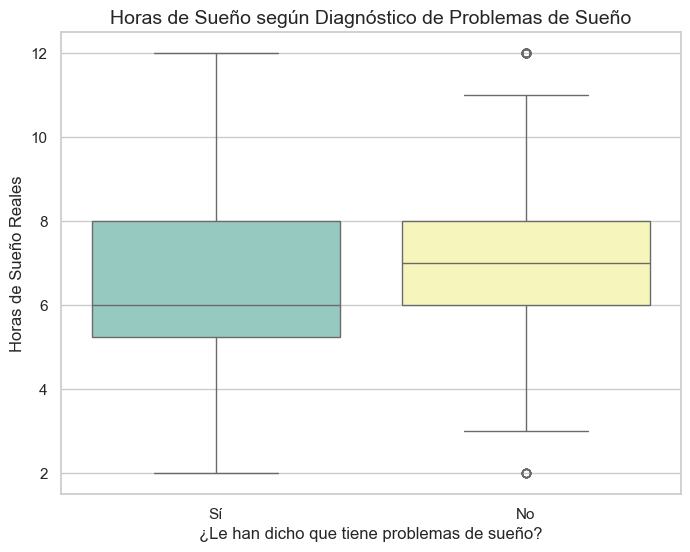

In [40]:
plt.figure(figsize=(8, 6))

# Mapeamos los valores para que el gráfico se explique solo
slq_plot = slq.copy()
slq_plot['Trouble_Sleep'] = slq_plot['SLQ050'].map({1: 'Sí', 0: 'No'})

sns.boxplot(data=slq_plot, x='Trouble_Sleep', y='SLD010H', palette='Set3')
plt.title('Horas de Sueño según Diagnóstico de Problemas de Sueño', fontsize=14)
plt.xlabel('¿Le han dicho que tiene problemas de sueño?')
plt.ylabel('Horas de Sueño Reales')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_14208\1128480519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=prevalencia.index, y=prevalencia.values, palette='viridis')


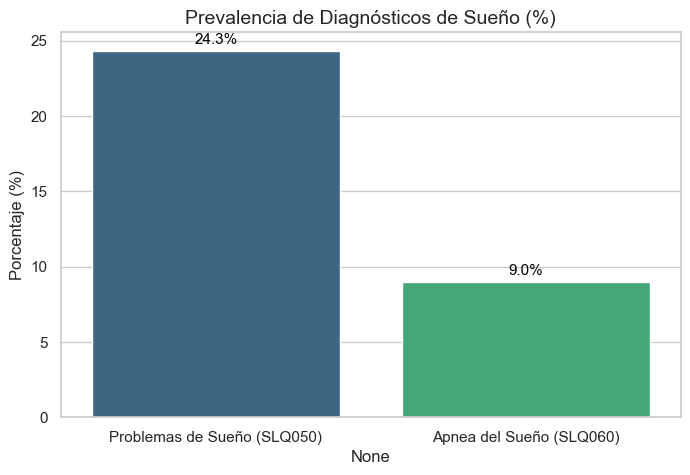

In [41]:
# Preparamos los datos para un gráfico de barras comparativo
prevalencia = slq[['SLQ050', 'SLQ060']].mean() * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=prevalencia.index, y=prevalencia.values, palette='viridis')

plt.title('Prevalencia de Diagnósticos de Sueño (%)', fontsize=14)
plt.xticks([0, 1], ['Problemas de Sueño (SLQ050)', 'Apnea del Sueño (SLQ060)'])
plt.ylabel('Porcentaje (%)')

# Anotar los porcentajes sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

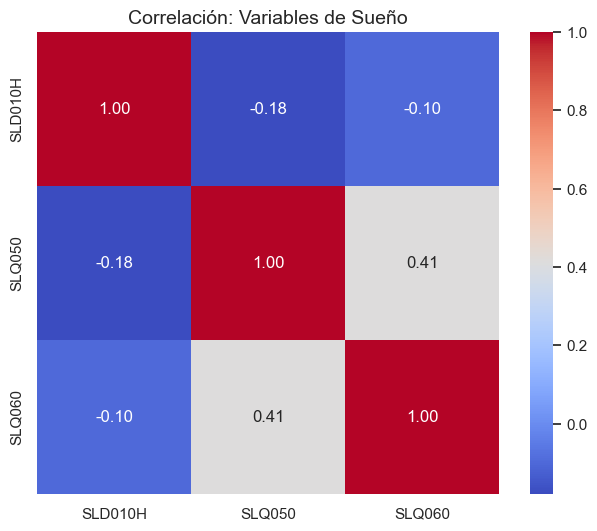

In [42]:
plt.figure(figsize=(8, 6))
corr_slq = slq.drop(columns=['SEQN']).corr()

sns.heatmap(corr_slq, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlación: Variables de Sueño', fontsize=14)
plt.show()